# TGV² objective — learned vs PDHG

Plots the **real minimisation objective**

$$F(u,w)=\tfrac12\lVert A u - y\rVert^2+\alpha_1\lVert\nabla u - w\rVert_1+\alpha_2\lVert E w\rVert_1$$

for the two solvers of the **same** TGV² tomography problem:

* **learned** — the unrolled scheme (`run_learned`), and
* **pdhg** — the Chambolle–Pock baseline (`pdhg_tomography_tgv.run_pdhg`).

The objective is built once in `Algo_setuptorch.make_objective` from the same
normalised `A`, sinogram `y` and the `∇`, `E` operators of the setup (the exact
functional minimised by PDHG and used as the training loss). Because both curves
use the *same* `F`, they are strictly comparable.

## 1. Config

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

SIZE       = 128
N_ANGLES   = 180
SEED       = 1000
NOISE      = 0.05
T          = 100# learned iterations to plot
PDHG_ITERS = T     
CHECKPOINT        = "objectif_tomo_128_gamma_2.pt"   # trained learned model
CHECKPOINT_NOSAFE = "trained_models/objectif_nosafe_tomo_128_gamma_1.8.pt"       # model trained WITHOUT safeguarding
RANDOM_SEED       = 0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [2]:
from pathlib import Path

PLOTS_DIR = Path('plots')
PLOTS_DIR.mkdir(exist_ok=True)


def save_figure_pdf(fig, stem):
    safe_stem = stem.replace(' ', '_').replace('/', '_')
    fig.savefig(PLOTS_DIR / f'{safe_stem}_{T}.pdf', bbox_inches='tight')

## 2. Build the problem (same setup as the algorithm)

In [3]:
from Algo_setuptorch import Params, get_setup, build_algo_functions

params    = Params(size=SIZE)
setup     = get_setup(SIZE, n_angles=N_ANGLES, seed=SEED,
                      noise_level=NOISE, device=device)
functions = build_algo_functions(setup, params)

SHAPES = [(1, 1, SIZE, SIZE),   # u  (image)
          (1, 2, SIZE, SIZE),   # w
          (1, 2, SIZE, SIZE),   # p
          (1, 3, SIZE, SIZE)]   # q

initial_state = setup["initial_state"]
clean         = setup["phantom"]
print(f"gamma = {params.gamma0:.4f}   beta_bar = {params.beta_bar:.3f}")
print(f"alpha1 = {params.alpha1}   alpha2 = {params.alpha2}")

gamma = 2.0000   beta_bar = 1.000
alpha1 = 0.004   alpha2 = 0.04


## 3. The TGV² objective $F(u,w)$  (built with ODL)

`make_objective(setup, params)` returns a callable `objective(u, w) -> float` using the
normalised `A`, sinogram `y` and the `∇`, `E` operators of the setup, with the
anisotropic ℓ¹ norms — identical to the PDHG functional. The same callable is
passed to PDHG (`obj_fn=`) and applied to the learned iterates.

In [4]:
from Algo_setuptorch import make_objective, objective_history

objective = make_objective(setup, params)
print("objective built. alpha1, alpha2 =", objective.alpha1, objective.alpha2)

objective built. alpha1, alpha2 = 0.004 0.04


## 4. Learned scheme

In [ ]:
from algorithm.unrolled_model import UnrolledFBS
from algorithm.run import run_learned

model = UnrolledFBS(params=params, shapes=SHAPES, n_channels=3,
                    T=10, alpha=0.9).to(device).float()

ckpt  = torch.load(CHECKPOINT, map_location=device)
state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
model.load_state_dict(state)
model.eval()

kkt_learned, res_learned, hist = run_learned(
    model, initial_state, clean, functions, T_test=T, return_all=True)
obj_learned = objective_history(objective, hist["x"])
print("F_learned:", obj_learned[0], "->", obj_learned[-1])

iter:0
52.57222366333008
iter:1
38.71213150024414
iter:2
27.65439796447754
iter:3
17.9193058013916
iter:4
12.215396881103516
iter:5
7.733400344848633
iter:6
5.055281639099121
iter:7
3.164247512817383
iter:8
2.208742380142212
iter:9
1.4566065073013306
iter:10
1.13938307762146
iter:11
0.7669673562049866
iter:12
0.6416013240814209
iter:13
0.4349733591079712
iter:14
0.3855957090854645
iter:15
0.26378029584884644
iter:16
0.24244695901870728
iter:17
0.1708066314458847
iter:18
0.16229282319545746
iter:19
0.11789117008447647
iter:20
0.11784818768501282
iter:21
0.0894780308008194
iter:22
0.0931888297200203
iter:23
0.07437916845083237
iter:24
0.0774042159318924
iter:25
0.06650490313768387
iter:26
0.06839478760957718
iter:27
0.06128241866827011
iter:28
0.06390869617462158
iter:29
0.05753857642412186
iter:30
0.05690738186240196
iter:31
0.05210389569401741
iter:32
0.051467735320329666
iter:33
0.05008474737405777
iter:34
0.047661930322647095
iter:35
0.045264024287462234
iter:36
0.044124722480773926


## 5. PDHG baseline

`run_pdhg` records `objective(u, w)` at every iteration through its `obj_fn`
callback, so we get the PDHG objective curve directly.

In [ ]:
from utils.pdhg_tomography_tgv import run_pdhg

rec_pdhg, obj_pdhg = run_pdhg(setup, params, niter=PDHG_ITERS,
                             verbose=False, obj_fn=objective)
obj_pdhg = np.asarray(obj_pdhg)
print("F_pdhg:", obj_pdhg[0], "->", obj_pdhg[-1])

F_pdhg: 1986.18505859 -> 18.1287670135


## 5b. Extra baselines — zero, random, learned-without-safeguard

Three more curves on the *same* objective $F$:

* **zero** — the plain forward-backward iteration (no deviation), `run_zero`.
* **random** — feasible but *random* deviations (safeguarded direction is random), `run_random`.
* **learned (no safeguard)** — the learned scheme with the budget projection removed (`run_learned_nosafe`), using a model trained specifically without safeguarding. No convergence guarantee: expected to do well early, then plateau/diverge.

In [ ]:
from algorithm.run import run_zero, run_random, run_learned_nosafe

# zero-deviation baseline 
kkt_zero, res_zero, xhist_zero = run_zero(
    initial_state, functions, params, SHAPES, T=T, device=device)
obj_zero = objective_history(objective, xhist_zero)

# random feasible deviations (safeguarded magnitude, random direction)
kkt_rand, res_rand, xhist_rand = run_random(
    initial_state, functions, params, SHAPES, T=T, device=device,
    alpha=0.99, seed=RANDOM_SEED)
obj_rand = objective_history(objective, xhist_rand)

""" # learned WITHOUT safeguarding (its own checkpoint)
model_ns = UnrolledFBS(params=params, shapes=SHAPES, n_channels=3,
                       T=10, alpha=0.9).to(device).float()
ckpt_ns  = torch.load(CHECKPOINT_NOSAFE, map_location=device)
state_ns = ckpt_ns["model"] if isinstance(ckpt_ns, dict) and "model" in ckpt_ns else ckpt_ns
model_ns.load_state_dict(state_ns)
model_ns.eval()
kkt_ns, res_ns, hist_ns = run_learned_nosafe(
    model_ns, initial_state, clean, functions, T_test=T, return_all=True)
obj_nosafe = objective_history(objective, hist_ns["x"])  """

import numpy as np
obj_zero, obj_rand = map(np.asarray, (obj_zero, obj_rand))
for name, c in [("zero", obj_zero), ("random", obj_rand),
                ("learned", obj_learned), 
                ("pdhg", obj_pdhg)]:
    print(f"{name:8s}: {c[0]:.3e} -> {c[-1]:.3e}")
    
import numpy as np
obj_zero, obj_rand = map(np.asarray, (obj_zero, obj_rand))
for name, c in [("zero", obj_zero), ("random", obj_rand),
                ("learned", obj_learned)   ,
                ("pdhg", obj_pdhg)]:
    print(f"{name:8s}: {c[0]:.3e} -> {c[-1]:.3e}")

iter:0
40.845401763916016
iter:1
25.318384170532227
iter:2
15.703790664672852
iter:3
9.748969078063965
iter:4
6.060128688812256
iter:5
3.7779812812805176
iter:6
2.3689866065979004
iter:7
1.5038542747497559
iter:8
0.9794886708259583
iter:9
0.6701530814170837
iter:10
0.4961133599281311
iter:11
0.4039590358734131
iter:12
0.3570806682109833
iter:13
0.33275526762008667
iter:14
0.31882065534591675
iter:15
0.3095422089099884
iter:16
0.30236321687698364
iter:17
0.2961781620979309
iter:18
0.29049843549728394
iter:19
0.2851080000400543
iter:20
0.279906302690506
iter:21
0.27484679222106934
iter:22
0.26990750432014465
iter:23
0.2650798261165619
iter:24
0.2603616416454315
iter:25
0.25575530529022217
iter:26
0.25126519799232483
iter:27
0.24689672887325287
iter:28
0.24265559017658234
iter:29
0.238546684384346
iter:30
0.23457449674606323
iter:31
0.23074252903461456
iter:32
0.22705355286598206
iter:33
0.2235092967748642
iter:34
0.22011086344718933
iter:35
0.21685843169689178
iter:36
0.21375137567520142

## 6. Objective $F(x_n)$ — learned vs PDHG

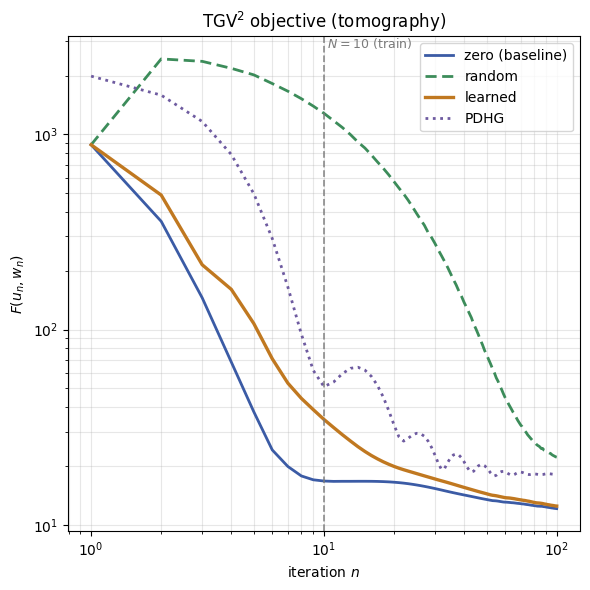

In [ ]:
PAPER = {"blue":"#3B5BA5","orange":"#C07820","green":"#3C8C5A",
         "red":"#B5485D","purple":"#6E5BA0","gray":"#7A7A7A"}
def _t(c): return np.arange(1, len(c) + 1)

series = [
    ("zero (baseline)",        obj_zero,    PAPER["blue"],   "-",        2.0),
    ("random",                 obj_rand,    PAPER["green"],  (0,(4,2)),  2.0),
    ("learned",                obj_learned, PAPER["orange"], "-",        2.4),
    #("learned (no safeguard)", obj_nosafe,  PAPER["red"],    "--",       2.0),
    ("PDHG",                   obj_pdhg,    PAPER["purple"], ":",        2.0),
]

plt.figure(figsize=(6, 6))
for name, c, col, ls, lw in series:
    plt.loglog(_t(c), c, label=name, color=col, lw=lw, ls=ls)

# training horizon: the network is trained on N=10 iterations
plt.axvline(10, color=PAPER["gray"], lw=1.3, ls="--", alpha=0.8)
plt.text(10, plt.ylim()[1], r" $N=10$ (train)", color=PAPER["gray"],
         va="top", ha="left", fontsize=9)

plt.xlabel("iteration $n$")
plt.ylabel(r"$F(u_n, w_n)$")
plt.title(r"TGV$^2$ objective (tomography)")
plt.legend(); plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
save_figure_pdf(plt.gcf(), 'on_objective_learned_vs_pdhg')
plt.show()

## 7. Objective gap $F(x_n)-F^\star$

$F^\star$ is the lowest objective reached by **either** run (learned or PDHG).
Once a run gets within machine precision of $F^\star$, the gap underflows and
$\log(F-F^\star)$ would dive to $-\infty$. To avoid that artefact we **stop each
curve a bit before** that point: it is truncated at the first iterate whose gap
drops to/under a small floor $\varepsilon_{\mathrm{rel}}\,|F^\star|$ (above the
float32 resolution $\sim 10^{-7}$). Tune `EPS_REL` to cut earlier/later.

F* = 1.20995712e+01


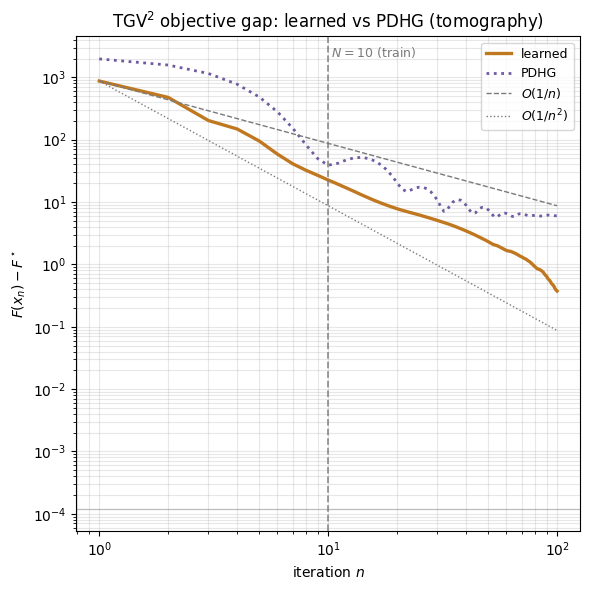

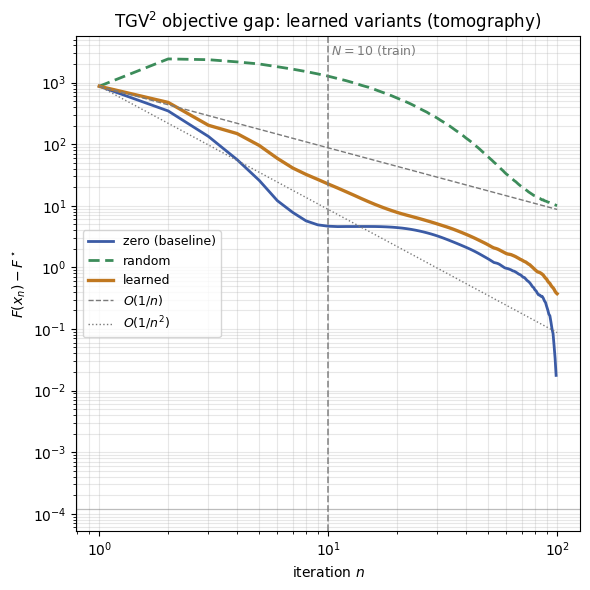

In [ ]:
# F* = lowest objective reached by ANY method.
F_star = float(min(c.min() for _, c, *_ in series))
print(f"F* = {F_star:.8e}")

EPS_REL = 1e-5
floor   = EPS_REL * max(abs(F_star), 1.0)

def _truncate(gap):
    """Keep iterates up to (but not including) the first one at/under floor,
    so log(F - F*) does not dive to -inf at machine precision."""
    below = np.where(gap <= floor)[0]
    end   = int(below[0]) if below.size else len(gap)
    return np.arange(1, max(end, 1) + 1), gap[:max(end, 1)]

# O(1/n), O(1/n^2) guides anchored on the learned curve's first gap
g0 = float((obj_learned - F_star)[0]); tt = _t(obj_learned)

# Plot 1: learned vs PDHG
plt.figure(figsize=(6, 6))
for name, c, col, ls, lw in series:
    if name in ['learned', 'PDHG']:
        t, g = _truncate(c - F_star)
        plt.loglog(t, g, label=name, color=col, lw=lw, ls=ls)

plt.loglog(tt, g0/tt,    color=PAPER["gray"], lw=1.0, ls="--", label=r"$O(1/n)$")
plt.loglog(tt, g0/tt**2, color=PAPER["gray"], lw=1.0, ls=":",  label=r"$O(1/n^2)$")

plt.axvline(10, color=PAPER["gray"], lw=1.3, ls="--", alpha=0.8)
plt.text(10, plt.ylim()[1], r" $N=10$ (train)", color=PAPER["gray"],
         va="top", ha="left", fontsize=9)
plt.axhline(floor, color=PAPER["gray"], lw=0.9, alpha=0.5)

plt.xlabel("iteration $n$")
plt.ylabel(r"$F(x_n)-F^\star$")
plt.title(r"TGV$^2$ objective gap: learned vs PDHG (tomography)")
plt.legend(fontsize=9); plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
save_figure_pdf(plt.gcf(), 'on_objective_gap_learned_vs_pdhg')
plt.show()

# Plot 2: learned, zero, random, nosafe
plt.figure(figsize=(6, 6))
for name, c, col, ls, lw in series:
    if name in ['learned', 'zero (baseline)', 'random', 'learned (no safeguard)']:
        t, g = _truncate(c - F_star)
        plt.loglog(t, g, label=name, color=col, lw=lw, ls=ls)

plt.loglog(tt, g0/tt,    color=PAPER["gray"], lw=1.0, ls="--", label=r"$O(1/n)$")
plt.loglog(tt, g0/tt**2, color=PAPER["gray"], lw=1.0, ls=":",  label=r"$O(1/n^2)$")

plt.axvline(10, color=PAPER["gray"], lw=1.3, ls="--", alpha=0.8)
plt.text(10, plt.ylim()[1], r" $N=10$ (train)", color=PAPER["gray"],
         va="top", ha="left", fontsize=9)
plt.axhline(floor, color=PAPER["gray"], lw=0.9, alpha=0.5)

plt.xlabel("iteration $n$")
plt.ylabel(r"$F(x_n)-F^\star$")
plt.title(r"TGV$^2$ objective gap: learned variants (tomography)")
plt.legend(fontsize=9); plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
save_figure_pdf(plt.gcf(), 'on_objective_gap_learned_variants')
plt.show()